In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from tqdm import tqdm

In [14]:
DATA_PATH = "../../../data/preprocessed/selected_features_dataset.csv"
MODEL_PATH = "../../../models/xgboost/xgboost_model_label_v3.joblib"
ENCODER_PATH = "../../../data/processed/label_encoders_selected.pkl"
ANALYSIS_DIR = "../../../reports/address_analysis/"
CV_FOLDS = 5
RANDOM_STATE = 42
MIN_SAMPLES_PER_ADDRESS = 3 

In [3]:
os.makedirs(ANALYSIS_DIR, exist_ok=True)
print(f"Analysis outputs will be saved to: {ANALYSIS_DIR}")

Analysis outputs will be saved to: ../../../reports/address_analysis/


In [4]:
print("Loading and preparing data...")
df = pd.read_csv(DATA_PATH)
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

print(f"\nData loaded successfully:")
print(f"- Training samples: {len(X_train)}")
print(f"- Test samples: {len(X_test)}")

Loading and preparing data...

Data loaded successfully:
- Training samples: 7417
- Test samples: 1855


In [5]:
print("\nLoading model and encoders...")
try:
    xgboost_model = joblib.load(MODEL_PATH)
    print(f"Model loaded from {MODEL_PATH}")
    
    with open(ENCODER_PATH, 'rb') as f:
        label_encoder = pickle.load(f)
    print(f"Label encoder loaded from {ENCODER_PATH}")
    
except Exception as e:
    print(f"Error loading files: {str(e)}")
    raise


Loading model and encoders...
Model loaded from ../../../models/xgboost/xgboost_model_label_v3.joblib
Label encoder loaded from ../../../data/processed/label_encoders_selected.pkl


In [6]:
# Create a copy of the model without early stopping for CV
cv_model = xgboost_model.set_params(**{
    'early_stopping_rounds': None,
    'eval_set': None
})

print("\nRunning cross-validation...")
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_val_score(
    cv_model,  # Use the modified model
    X_train,
    y_train,
    cv=cv,
    scoring=make_scorer(r2_score),
    n_jobs=-1
)

print("\nCross-Validation Results:")
print(f"Mean R²: {cv_results.mean():.4f}")
print(f"Std R²: {cv_results.std():.4f}")
print(f"Range: {cv_results.min():.4f} - {cv_results.max():.4f}")



Running cross-validation...

Cross-Validation Results:
Mean R²: 0.9906
Std R²: 0.0019
Range: 0.9883 - 0.9936


In [9]:
from sklearn.model_selection import KFold

print("\nRunning cross-validation with early stopping...")
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for train_idx, val_idx in tqdm(cv.split(X_train), total=CV_FOLDS):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Clone the original model
    fold_model = xgboost_model.__class__(**xgboost_model.get_params())
    
    # Train with early stopping
    fold_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=0
    )
    
    # Score on validation fold
    score = r2_score(y_fold_val, fold_model.predict(X_fold_val))
    cv_scores.append(score)

print("\nCross-Validation Results with Early Stopping:")
print(f"Mean R²: {np.mean(cv_scores):.4f}")
print(f"Std R²: {np.std(cv_scores):.4f}")
print(f"Range: {np.min(cv_scores):.4f} - {np.max(cv_scores):.4f}")


Running cross-validation with early stopping...


100%|██████████| 5/5 [01:50<00:00, 22.04s/it]


Cross-Validation Results with Early Stopping:
Mean R²: 0.9907
Std R²: 0.0019
Range: 0.9886 - 0.9936


In [7]:
print("\nMaking predictions...")
y_pred_test = xgboost_model.predict(X_test)
y_pred_train = xgboost_model.predict(X_train)


Making predictions...


In [15]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test
})

if 'address_line_2' in X_test.columns:
    results_df['address_encoded'] = X_test['address_line_2'].values
    
    # Initialize address column with encoded values by default
    results_df['address'] = results_df['address_encoded']
    
    # Only try to decode if we have a valid encoder
    if (label_encoder is not None and 
        hasattr(label_encoder, 'get') and 
        label_encoder.get('address_line_2') is not None):
        
        try:
            results_df['address'] = label_encoder['address_line_2'].inverse_transform(
                results_df['address_encoded'].astype(int)
            )
        except Exception as e:
            print(f"Could not decode addresses, using encoded values. Error: {e}")

In [18]:
if 'address' in results_df.columns:
    print("\nAnalyzing performance by address...")
    
    # Calculate metrics per address
    address_metrics = []
    for address, group in tqdm(results_df.groupby('address'), desc="Processing addresses"):
        try:
            # Additional check for valid group data
            if len(group) >= MIN_SAMPLES_PER_ADDRESS and not group.empty:
                # Ensure we have both actual and predicted values
                if 'actual' in group.columns and 'predicted' in group.columns:
                    actual_vals = group['actual'].values
                    predicted_vals = group['predicted'].values
                    
                    # Check for valid numerical values
                    if (np.issubdtype(actual_vals.dtype, np.number) and 
                        np.issubdtype(predicted_vals.dtype, np.number)):
                        
                        metrics = {
                            'Address': str(address),  # Ensure address is string
                            'R2': r2_score(actual_vals, predicted_vals),
                            'MAE': mean_absolute_error(actual_vals, predicted_vals),
                            'Sample_Size': len(group),
                            'Actual_Mean': np.mean(actual_vals),
                            'Predicted_Mean': np.mean(predicted_vals),
                            'Error_Ratio': np.mean(np.abs(predicted_vals / np.maximum(actual_vals, 1e-6)))  # Avoid division by zero
                        }
                        address_metrics.append(metrics)
        except Exception as e:
            print(f"Error processing address {address}: {str(e)}")
            continue
    
    if address_metrics:
        metrics_df = pd.DataFrame(address_metrics).sort_values('R2', ascending=False)
        
        # Save metrics
        metrics_csv_path = os.path.join(ANALYSIS_DIR, 'address_performance_metrics.csv')
        metrics_df.to_csv(metrics_csv_path, index=False)
        
        # Print summary
        print("\nPerformance by Address:")
        print("-" * 70)
        print(f"Total addresses analyzed: {len(metrics_df)}")
        print(f"Addresses with R² > 0.7: {len(metrics_df[metrics_df['R2'] > 0.7])}")
        print(f"Addresses with R² < 0.3: {len(metrics_df[metrics_df['R2'] < 0.3])}")
        
        # Visualizations
        plt.figure(figsize=(15, 6))
        
        plt.subplot(1, 2, 1)
        sns.histplot(metrics_df['R2'], bins=20, kde=True)
        plt.title('Distribution of R² Scores by Address')
        plt.xlabel('R² Score')
        
        plt.subplot(1, 2, 2)
        sns.scatterplot(
            data=metrics_df, 
            x='MAE', 
            y='R2', 
            size='Sample_Size',
            hue='Sample_Size',
            palette='viridis',
            alpha=0.7
        )
        plt.title('MAE vs R² by Address')
        plt.tight_layout()
        plt.savefig(os.path.join(ANALYSIS_DIR, 'address_performance_summary.png'))
        plt.close()  # Use close() instead of show() in notebooks
        
        # Detailed plots for top/bottom performers
        for perf_type in ['Best', 'Worst']:
            subset = metrics_df.head(5) if perf_type == 'Best' else metrics_df.tail(5)
            
            fig, axes = plt.subplots(2, 3, figsize=(12, 8))
            axes = axes.flatten()
            
            for i, (_, row) in enumerate(subset.iterrows()):
                if i >= len(axes):  # Don't exceed subplot count
                    break
                    
                addr_data = results_df[results_df['address'] == row['Address']]
                ax = axes[i]
                
                ax.scatter(addr_data['actual'], addr_data['predicted'], alpha=0.6)
                ax.plot([addr_data['actual'].min(), addr_data['actual'].max()],
                       [addr_data['actual'].min(), addr_data['actual'].max()], 'r--')
                ax.set_title(f"{row['Address'][:15]}...\nR²: {row['R2']:.2f}")
                ax.set_xlabel('Actual')
                ax.set_ylabel('Predicted')
            
            plt.suptitle(f"{perf_type} 5 Performing Addresses", y=1.02)
            plt.tight_layout()
            plt.savefig(os.path.join(ANALYSIS_DIR, f'{perf_type.lower()}_performers.png'))
            plt.close()
    else:
        print("No addresses with sufficient samples for analysis")
else:
    print("\nNo address information available for analysis")


Analyzing performance by address...


Processing addresses:   0%|          | 0/96 [00:00<?, ?it/s]

Processing addresses: 100%|██████████| 96/96 [00:00<00:00, 345.87it/s]



Performance by Address:
----------------------------------------------------------------------
Total addresses analyzed: 91
Addresses with R² > 0.7: 26
Addresses with R² < 0.3: 35


In [19]:
print("\nModel Evaluation Summary:")
print("=" * 70)
print(f"{'Metric':<20}{'Train':>15}{'Test':>15}{'CV Mean':>15}")
print("-" * 70)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"{'R²':<20}{train_r2:>15.4f}{test_r2:>15.4f}{cv_results.mean():>15.4f}")
print(f"{'MAE':<20}{train_mae:>15.4f}{test_mae:>15.4f}{'':>15}")
print(f"{'RMSE':<20}{train_rmse:>15.4f}{test_rmse:>15.4f}{'':>15}")


Model Evaluation Summary:
Metric                        Train           Test        CV Mean
----------------------------------------------------------------------
R²                           0.9968         0.9920         0.9906
MAE                         46.5396        96.9227               
RMSE                       131.0216       203.1532               



Plotting feature importance...


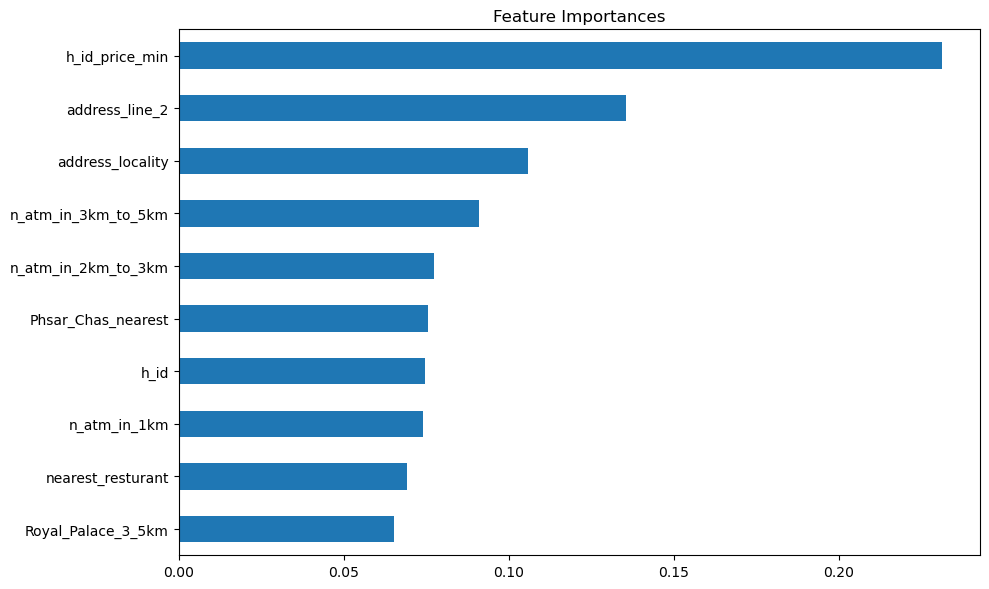

In [20]:
if hasattr(xgboost_model, 'feature_importances_'):
    print("\nPlotting feature importance...")
    plt.figure(figsize=(10, 6))
    importances = pd.Series(
        xgboost_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)
    
    # Only show top 20 features if there are many
    if len(importances) > 20:
        importances = importances[-20:]
    
    importances.plot(kind='barh')
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, 'feature_importances.png'), dpi=300)
    plt.show()
else:
    print("\nFeature importances not available for this model")